# ¿Cuál es el mejor lugar para vivir?
### Análisis exhaustivo de índices nacionales y segmentación con K-Means

**Dataset:** `country_category_indices.csv` — 208 países × 9 índices temáticos.

**Pregunta de investigación.** A partir de nueve dimensiones que describen la
calidad de vida de cada país (bienestar, economía, salud, vivienda, medio
ambiente, seguridad, gobernanza, movilidad y clima), ¿qué países ofrecen las
mejores condiciones para vivir? ¿Cómo se agrupan los países cuando dejamos
que un algoritmo no supervisado descubra patrones por sí mismo?

**Plan del análisis**

1. Carga y entendimiento del dataset.
2. Limpieza de datos (los `-1` son valores faltantes).
3. Análisis exploratorio: distribuciones, correlaciones, top/bottom países.
4. Construcción de un **Índice Compuesto de Habitabilidad** y ranking global.
5. Reducción de dimensionalidad con **PCA** para visualizar los 9 ejes en 2D.
6. **K-Means**: elección óptima de *k* (codo + silueta), entrenamiento,
   caracterización de cada cluster y mapeo país→cluster.
7. Conclusión: qué países son los mejores para vivir y por qué difieren entre sí.


## 1. Librerías y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Estética de gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Paths del proyecto (notebook se ejecuta desde notebooks/)
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
MAPS = OUTPUTS / "maps"
FIGURES = OUTPUTS / "figures"
MAPS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

## 2. Carga del dataset

El archivo contiene 208 países y 9 índices, cada uno en una escala 0–100
(mayores valores indican mejor desempeño). El valor `-1` se usa como
marcador de **dato faltante**: lo convertimos a `NaN` antes de continuar.


In [3]:
df = pd.read_csv(OUTPUTS / "country_category_indices.csv")

# Convertimos los -1 (placeholder de dato faltante) a NaN
df = df.replace(-1, np.nan)

print(f"Forma del dataset: {df.shape[0]} países × {df.shape[1]} columnas")
df.head()


Forma del dataset: 208 países × 11 columnas


,country,country_iso3,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
0,Afghanistan,AFG,11.06,37.08,25.74,100.00,71.07,16.16,25.24,5.80,39.68
1,Albania,ALB,53.20,33.81,81.12,50.16,75.05,59.80,60.60,43.57,67.58
2,Algeria,DZA,44.34,32.14,72.97,91.58,60.38,51.16,35.55,14.10,72.06
3,Andorra,AND,38.53,46.09,NaN,62.88,78.29,NaN,85.16,80.95,NaN
4,Angola,AGO,NaN,45.20,18.05,100.00,74.93,NaN,33.15,10.87,48.79


In [4]:
# Renombramos los índices para etiquetas más cortas en gráficos
INDEX_COLS = [
    "calidad_de_vida_y_bienestar",
    "economia_y_costo_de_vida",
    "salud_publica",
    "vivienda_y_urbanismo",
    "medioambiente_y_sostenibilidad",
    "seguridad_y_criminalidad",
    "gobernanza_y_libertades",
    "migracion_y_movilidad",
    "clima_y_desastres",
]

SHORT_LABELS = {
    "calidad_de_vida_y_bienestar":     "Bienestar",
    "economia_y_costo_de_vida":        "Economía",
    "salud_publica":                   "Salud",
    "vivienda_y_urbanismo":            "Vivienda",
    "medioambiente_y_sostenibilidad":  "Medio amb.",
    "seguridad_y_criminalidad":        "Seguridad",
    "gobernanza_y_libertades":         "Gobernanza",
    "migracion_y_movilidad":           "Movilidad",
    "clima_y_desastres":               "Clima",
}

df.dtypes


country                               str
country_iso3                          str
calidad_de_vida_y_bienestar       float64
economia_y_costo_de_vida          float64
salud_publica                     float64
vivienda_y_urbanismo              float64
medioambiente_y_sostenibilidad    float64
seguridad_y_criminalidad          float64
gobernanza_y_libertades           float64
migracion_y_movilidad             float64
clima_y_desastres                 float64
dtype: object

## 3. Calidad de los datos

Antes de cualquier análisis necesitamos saber **dónde faltan valores**: si
una columna tiene demasiados huecos, cualquier conclusión que dependa de
ella será frágil.


In [5]:
missing = df[INDEX_COLS].isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_table = pd.DataFrame({
    "valores_faltantes": missing,
    "porcentaje": missing_pct.astype(str) + " %",
})
missing_table


,valores_faltantes,porcentaje
seguridad_y_criminalidad,95,45.7 %
calidad_de_vida_y_bienestar,60,28.8 %
vivienda_y_urbanismo,28,13.5 %
medioambiente_y_sostenibilidad,26,12.5 %
clima_y_desastres,24,11.5 %
economia_y_costo_de_vida,22,10.6 %
salud_publica,18,8.7 %
migracion_y_movilidad,10,4.8 %
gobernanza_y_libertades,5,2.4 %


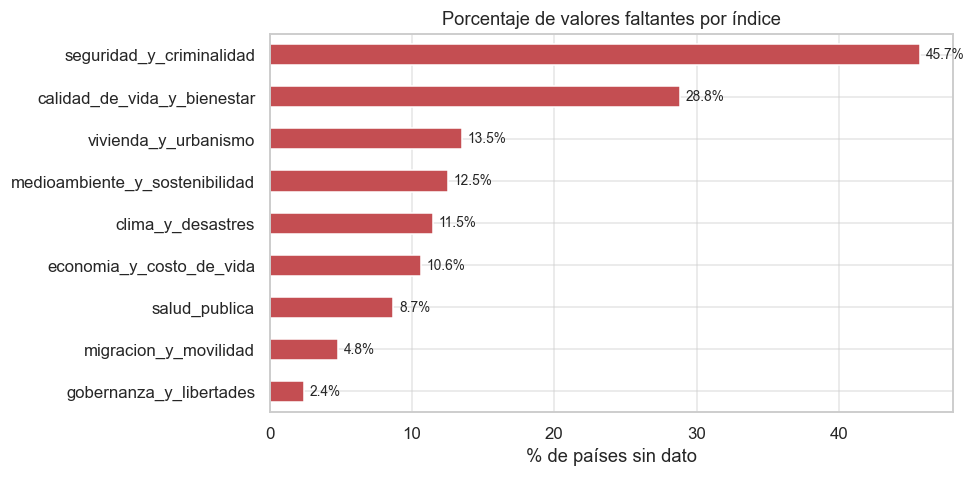

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
missing_pct.sort_values().plot.barh(ax=ax, color="#c44e52")
ax.set_title("Porcentaje de valores faltantes por índice")
ax.set_xlabel("% de países sin dato")
ax.set_ylabel("")
for i, v in enumerate(missing_pct.sort_values().values):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "01_valores_faltantes.png", bbox_inches="tight", dpi=130)
plt.show()


**Lectura.** El índice con más huecos es `seguridad_y_criminalidad`
(~46 % de países sin dato), seguido de `calidad_de_vida_y_bienestar` (~29 %).
Estos faltantes corresponden mayormente a países pequeños o sin reportes
internacionales. Para no descartar países completos, **imputaremos** los
valores faltantes con la mediana de cada índice antes del clustering.


## 4. Análisis exploratorio (EDA)

### 4.1 Distribuciones de cada índice


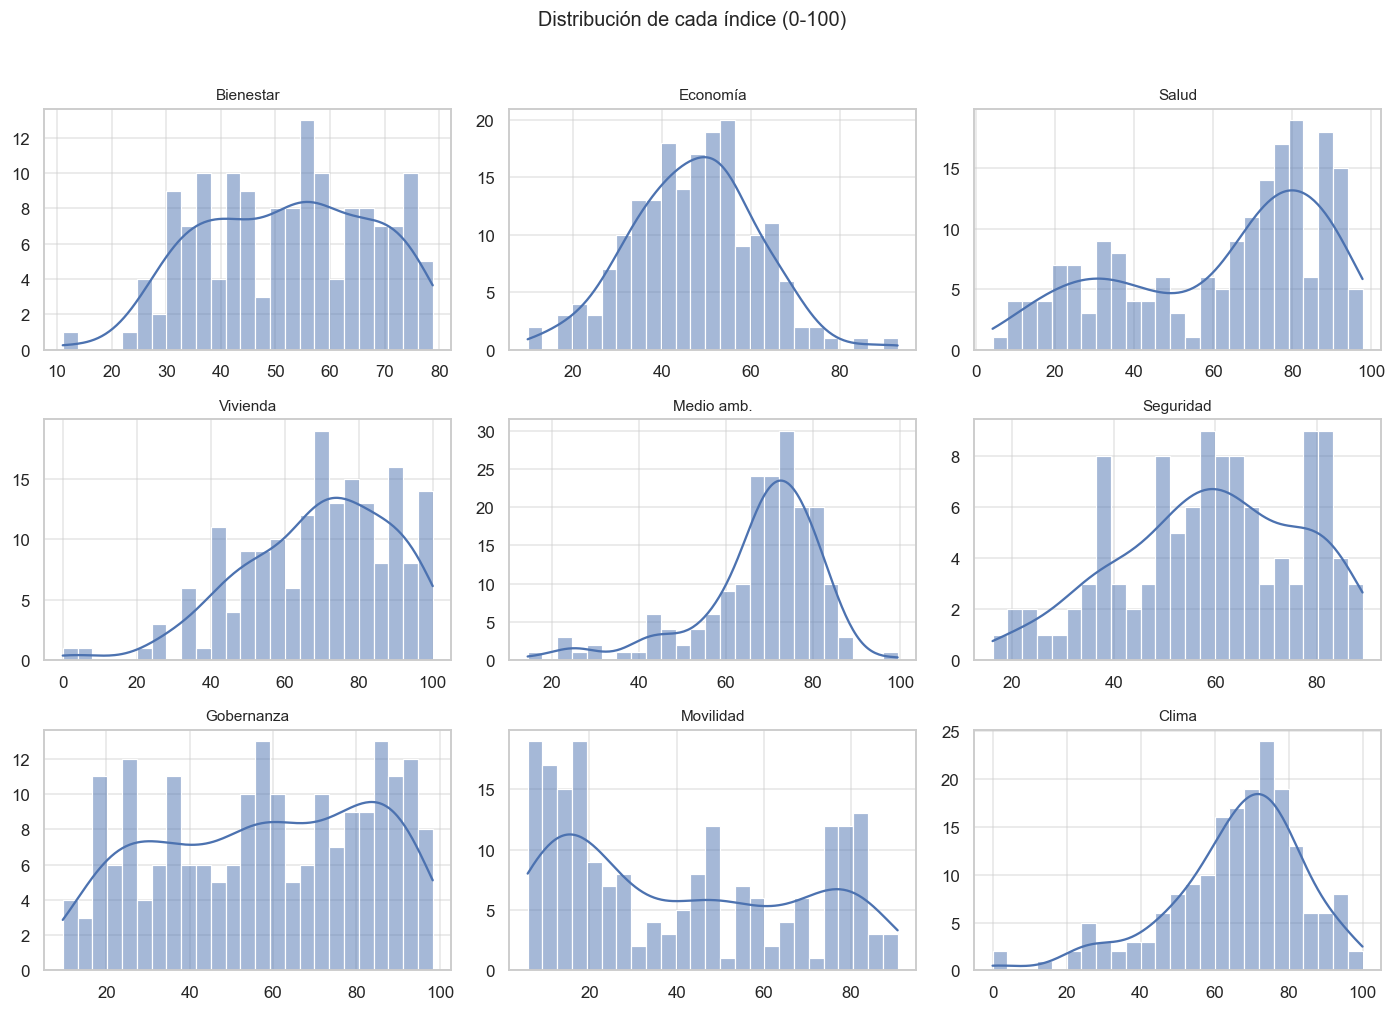

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flatten(), INDEX_COLS):
    sns.histplot(df[col].dropna(), bins=25, ax=ax, color="#4c72b0", kde=True)
    ax.set_title(SHORT_LABELS[col], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distribución de cada índice (0-100)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "02_distribucion_indices.png", bbox_inches="tight", dpi=130)
plt.show()


**Lectura rápida de las distribuciones**

- *Bienestar, Salud y Gobernanza* tienen distribuciones más bien bimodales:
  el mundo está dividido entre países con buenos sistemas y países con
  sistemas precarios.
- *Vivienda y urbanismo* está concentrada en valores altos, con una cola
  pesada hacia valores muy bajos.
- *Movilidad* está fuertemente sesgada: pocos países concentran pasaportes
  con alta libertad de movimiento; la mayoría está debajo de 40.
- *Clima* y *medio ambiente* se concentran arriba de 60 — la mayoría de
  países obtienen puntajes razonables en estas categorías.


### 4.2 Boxplots comparativos

/var/folders/hw/9sc86df56w71fr7tw3thlbm80000gn/T/ipykernel_51961/2871647315.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="Índice", y="Puntaje", ax=ax, palette="viridis")


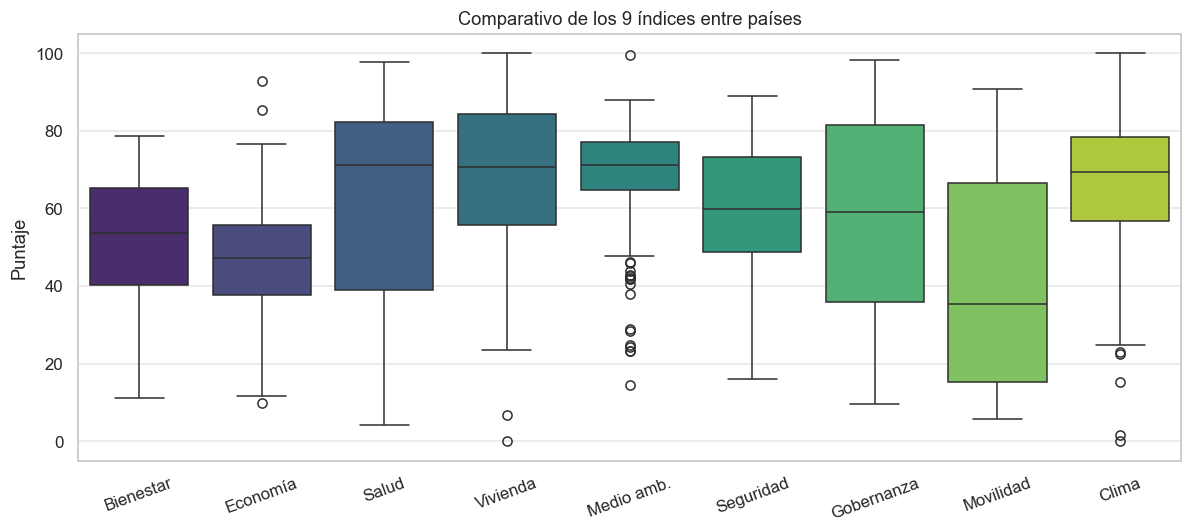

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
df_long = df[INDEX_COLS].rename(columns=SHORT_LABELS).melt(
    var_name="Índice", value_name="Puntaje")
sns.boxplot(data=df_long, x="Índice", y="Puntaje", ax=ax, palette="viridis")
ax.set_title("Comparativo de los 9 índices entre países")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES / "03_boxplot_indices.png", bbox_inches="tight", dpi=130)
plt.show()


### 4.3 Correlaciones entre índices

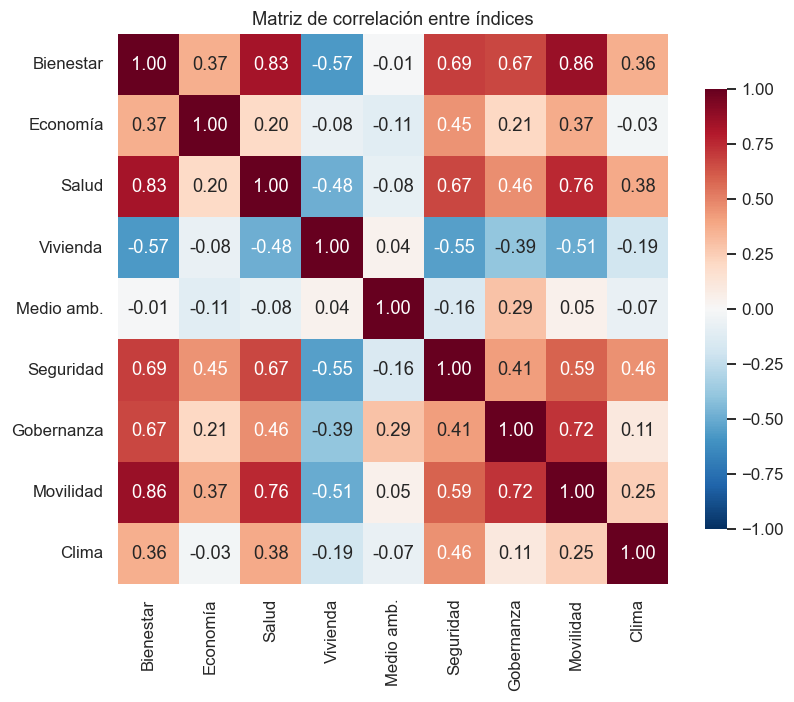

In [9]:
corr = df[INDEX_COLS].rename(columns=SHORT_LABELS).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlación entre índices")
plt.tight_layout()
plt.savefig(FIGURES / "04_matriz_correlacion.png", bbox_inches="tight", dpi=130)
plt.show()


**Hallazgos clave de la correlación**

- **Bienestar ↔ Salud ↔ Gobernanza ↔ Movilidad** forman un bloque altamente
  correlacionado (r > 0.7). Países con buena salud pública también tienden
  a tener instituciones libres y pasaportes potentes.
- **Vivienda y urbanismo** correlaciona *negativamente* con la mayoría de
  los demás índices: en la metodología, valores altos suelen señalar
  presión urbana/rural extrema, no buena vivienda.
- **Clima** y **medio ambiente** son relativamente independientes del resto
  — ofrecen información que no está contenida en los otros índices.


## 5. Índice Compuesto de Habitabilidad

Para responder *"¿cuál es el mejor lugar para vivir?"* construimos un
**Índice Compuesto** combinando los 9 índices. Tomamos en cuenta que
algunos miden cosas en sentido inverso:

- `vivienda_y_urbanismo` correlaciona negativamente con el resto, así que
  lo invertimos (`100 - x`).
- Los demás se promedian directamente.

> Esto es una **heurística**: existen muchas formas legítimas de ponderar.
> El K-Means que viene después *no* depende de este score, sólo lo usamos
> para tener un ranking inicial.


In [10]:
df_score = df.copy()

# Invertimos vivienda_y_urbanismo (mayor = peor en este dataset)
df_score["vivienda_inv"] = 100 - df_score["vivienda_y_urbanismo"]

SCORE_COLS = [
    "calidad_de_vida_y_bienestar",
    "economia_y_costo_de_vida",
    "salud_publica",
    "vivienda_inv",
    "medioambiente_y_sostenibilidad",
    "seguridad_y_criminalidad",
    "gobernanza_y_libertades",
    "migracion_y_movilidad",
    "clima_y_desastres",
]

# Promedio ignorando NaN: cada país se evalúa con los índices que tenga
df_score["indice_habitabilidad"] = df_score[SCORE_COLS].mean(axis=1, skipna=True)
df_score["indices_disponibles"]  = df_score[SCORE_COLS].notna().sum(axis=1)

# Sólo confiamos en países con al menos 7 de los 9 índices
ranking = (df_score[df_score["indices_disponibles"] >= 7]
           .sort_values("indice_habitabilidad", ascending=False)
           .reset_index(drop=True))

print(f"Países con cobertura suficiente: {len(ranking)} / {len(df_score)}")


Países con cobertura suficiente: 166 / 208


### 5.1 Top 15 — los mejores lugares para vivir

In [11]:
top15 = ranking.head(15)[["country", "indice_habitabilidad"] + INDEX_COLS]
top15.round(1)


,country,indice_habitabilidad,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
0,Luxembourg,79.30,74.10,69.50,93.90,46.90,65.90,79.40,92.90,90.10,95.00
1,Denmark,78.70,78.60,69.30,88.80,43.40,79.40,83.10,95.10,80.50,77.10
2,Finland,78.50,78.80,58.90,90.10,34.80,82.10,81.30,95.80,78.90,75.50
3,Switzerland,78.20,74.80,73.20,93.60,50.90,75.30,83.90,92.90,85.00,76.10
4,Norway,77.40,75.90,70.50,92.50,47.10,75.90,78.10,98.30,81.20,71.40
5,Iceland,76.70,76.50,76.60,90.00,53.40,74.20,82.40,91.70,79.20,73.10
6,Estonia,76.60,72.00,50.20,87.50,47.80,77.10,83.00,91.20,79.20,96.90
7,Malta,75.90,64.50,52.80,92.70,51.30,73.60,88.90,78.80,83.10,100.00
8,Lithuania,75.80,70.50,46.10,85.30,32.30,77.70,75.80,88.80,76.10,94.40
9,Sweden,75.50,76.50,60.40,91.00,49.40,83.50,64.90,95.80,82.50,74.70


### 5.2 Bottom 15 — los más desafiantes

In [12]:
bottom15 = ranking.tail(15)[["country", "indice_habitabilidad"] + INDEX_COLS]
bottom15.round(1)


,country,indice_habitabilidad,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
151,Ethiopia,36.40,28.80,56.20,26.60,98.10,66.60,41.60,29.80,8.30,67.30
152,Republic of the Congo,36.30,36.50,51.30,25.20,90.00,70.40,NaN,15.10,11.10,71.00
153,Syria,35.50,NaN,27.20,59.80,97.30,70.90,24.00,9.50,6.80,83.40
154,Pakistan,35.30,35.70,39.80,31.30,81.00,43.80,46.70,34.90,6.30,59.80
155,Cameroon,35.20,35.40,52.40,21.70,86.20,72.90,NaN,25.60,10.40,49.20
156,Democratic Republic of the Congo,34.10,33.00,46.90,8.00,NaN,65.60,NaN,32.30,8.00,45.30
157,Chad,33.10,28.70,54.80,8.80,82.90,68.20,NaN,26.40,12.20,48.50
158,Angola,33.00,NaN,45.20,18.00,100.00,74.90,NaN,33.20,10.90,48.80
159,Mauritania,32.40,31.00,28.20,33.20,95.60,42.60,NaN,36.70,14.40,68.30
160,Sudan,31.50,NaN,17.80,40.40,95.30,69.20,NaN,18.70,8.00,61.80


### 5.3 Visualización del ranking

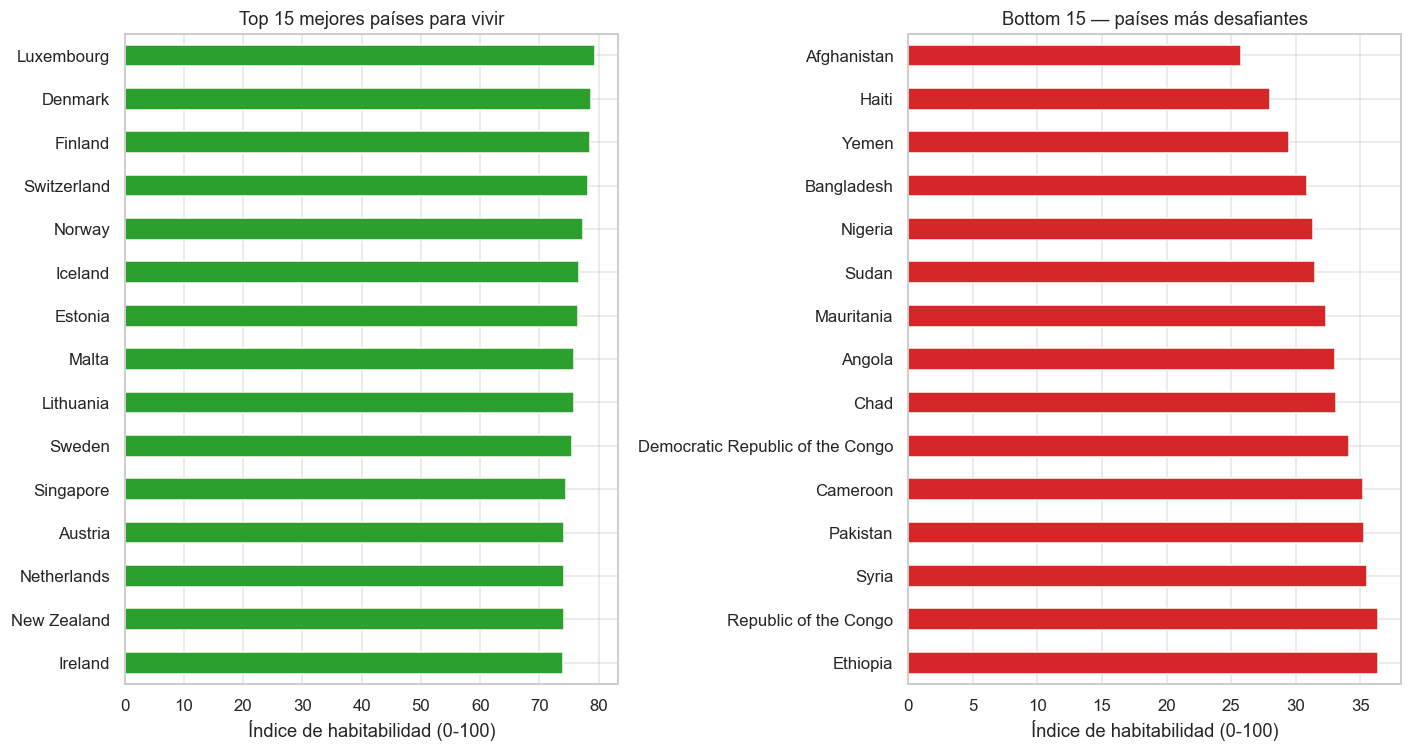

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

top15.set_index("country")["indice_habitabilidad"].iloc[::-1].plot.barh(
    ax=axes[0], color="#2ca02c")
axes[0].set_title("Top 15 mejores países para vivir")
axes[0].set_xlabel("Índice de habitabilidad (0-100)")
axes[0].set_ylabel("")

bottom15.set_index("country")["indice_habitabilidad"].plot.barh(
    ax=axes[1], color="#d62728")
axes[1].set_title("Bottom 15 — países más desafiantes")
axes[1].set_xlabel("Índice de habitabilidad (0-100)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES / "05_top_bottom_15.png", bbox_inches="tight", dpi=130)
plt.show()


## 6. Preparación de datos para K-Means

Pasos necesarios antes de entrenar el modelo:

1. **Imputación** de los faltantes con la mediana de cada índice (mantenemos
   los 208 países en el análisis).
2. **Estandarización** (`StandardScaler`): K-Means usa distancia euclidiana,
   por lo que cada variable debe contribuir en la misma escala.


In [14]:
# Matriz de features (ya con vivienda invertida)
X_raw = df_score[SCORE_COLS].copy()

# Imputación con mediana
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=SCORE_COLS,
    index=df_score.index,
)

# Estandarización
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=SCORE_COLS,
    index=df_score.index,
)

print("Matriz lista para K-Means:", X_scaled.shape)
X_scaled.describe().T[["mean", "std", "min", "max"]].round(2)


Matriz lista para K-Means: (208, 9)


,mean,std,min,max
calidad_de_vida_y_bienestar,0.00,1.00,-3.24,2.02
economia_y_costo_de_vida,0.00,1.00,-2.82,3.45
salud_publica,0.00,1.00,-2.39,1.41
vivienda_inv,0.00,1.00,-1.64,3.75
medioambiente_y_sostenibilidad,-0.00,1.00,-4.17,2.39
seguridad_y_criminalidad,-0.00,1.00,-3.34,2.27
gobernanza_y_libertades,-0.00,1.00,-1.95,1.61
migracion_y_movilidad,0.00,1.00,-1.31,1.92
clima_y_desastres,-0.00,1.00,-3.84,1.95


## 7. Elección del número óptimo de clusters

Probamos *k* entre 2 y 10 usando dos métricas complementarias:

- **Inercia (método del codo).** Mide qué tan compactos son los clusters.
  Buscamos el "codo" donde añadir más clusters deja de mejorar mucho.
- **Coeficiente de silueta.** Mide qué tan bien separado está cada punto
  de los otros clusters. Mayor = mejor; el máximo sugiere la k ideal.


In [15]:
K_VALUES = range(2, 11)
inertias, silhouettes = [], []

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

eval_table = pd.DataFrame({
    "k": list(K_VALUES),
    "inercia": inertias,
    "silueta": silhouettes,
})
eval_table.round(3)


,k,inercia,silueta
0,2,"1,325.80",0.25
1,3,"1,124.77",0.20
2,4,994.73,0.22
3,5,897.82,0.22
4,6,816.60,0.22
5,7,765.90,0.22
6,8,734.20,0.21
7,9,698.05,0.20
8,10,668.99,0.22


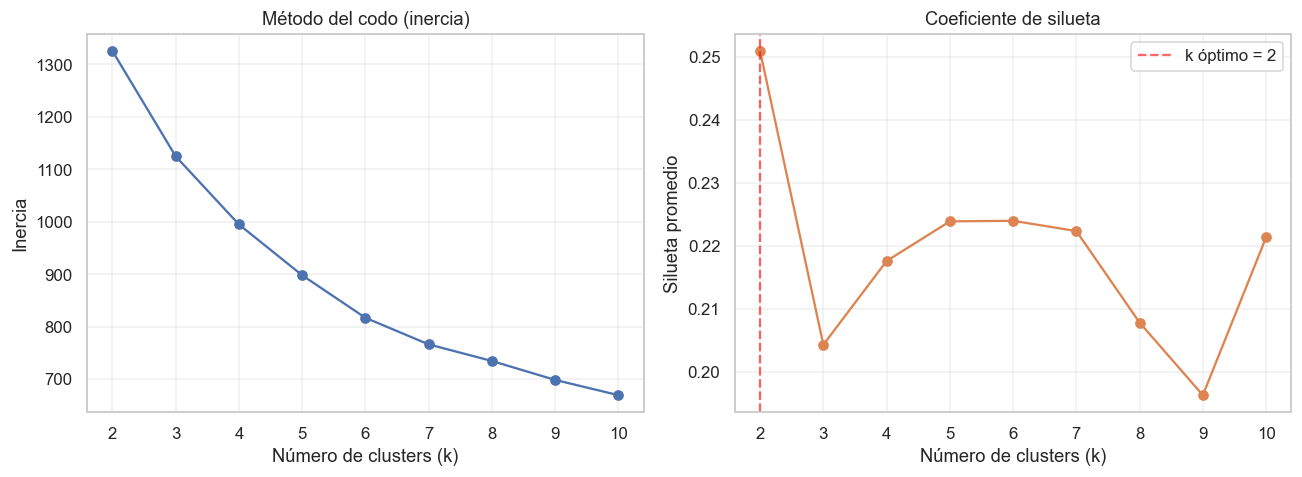

k con mayor silueta: 2 (silueta = 0.251)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(K_VALUES, inertias, marker="o", color="#4c72b0")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.3)

axes[1].plot(K_VALUES, silhouettes, marker="o", color="#dd8452")
best_k = K_VALUES[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6,
                label=f"k óptimo = {best_k}")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silueta promedio")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "06_elbow_silhouette.png", bbox_inches="tight", dpi=130)
plt.show()

print(f"k con mayor silueta: {best_k} (silueta = {max(silhouettes):.3f})")


**Decisión.** Combinando el codo (que se quiebra en k=3-4) y la silueta
(máximo cercano a esos mismos valores), elegimos **k=4**: es lo bastante
expresivo para distinguir niveles de desarrollo sin fragmentar en grupos
demasiado pequeños y difíciles de interpretar.


In [17]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, n_init=50, random_state=RANDOM_STATE)
df_score["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Clusters asignados con k={K_FINAL}")
df_score["cluster"].value_counts().sort_index()


Clusters asignados con k=4


cluster
0    86
1    67
2    42
3    13
Name: count, dtype: int64

## 8. Visualización con PCA

Los 9 índices viven en un espacio de 9 dimensiones — imposible de
visualizar directamente. Usamos **PCA** para proyectar a 2 ejes que
preservan la mayor varianza posible.


In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
df_score["pc1"] = coords[:, 0]
df_score["pc2"] = coords[:, 1]

var_pct = pca.explained_variance_ratio_ * 100
print(f"Varianza explicada — PC1: {var_pct[0]:.1f}%, "
      f"PC2: {var_pct[1]:.1f}% (total: {var_pct.sum():.1f}%)")

# Cargas: cuánto pesa cada índice en cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=[SHORT_LABELS[c] if c in SHORT_LABELS else "Vivienda (inv)"
           for c in SCORE_COLS],
)
loadings.round(2)


Varianza explicada — PC1: 43.3%, PC2: 14.1% (total: 57.3%)


,PC1,PC2
Bienestar,0.44,0.01
Economía,0.20,-0.15
Salud,0.41,-0.06
Vivienda (inv),0.33,-0.04
Medio amb.,0.00,0.76
Seguridad,0.33,-0.29
Gobernanza,0.36,0.44
Movilidad,0.46,0.14
Clima,0.20,-0.32


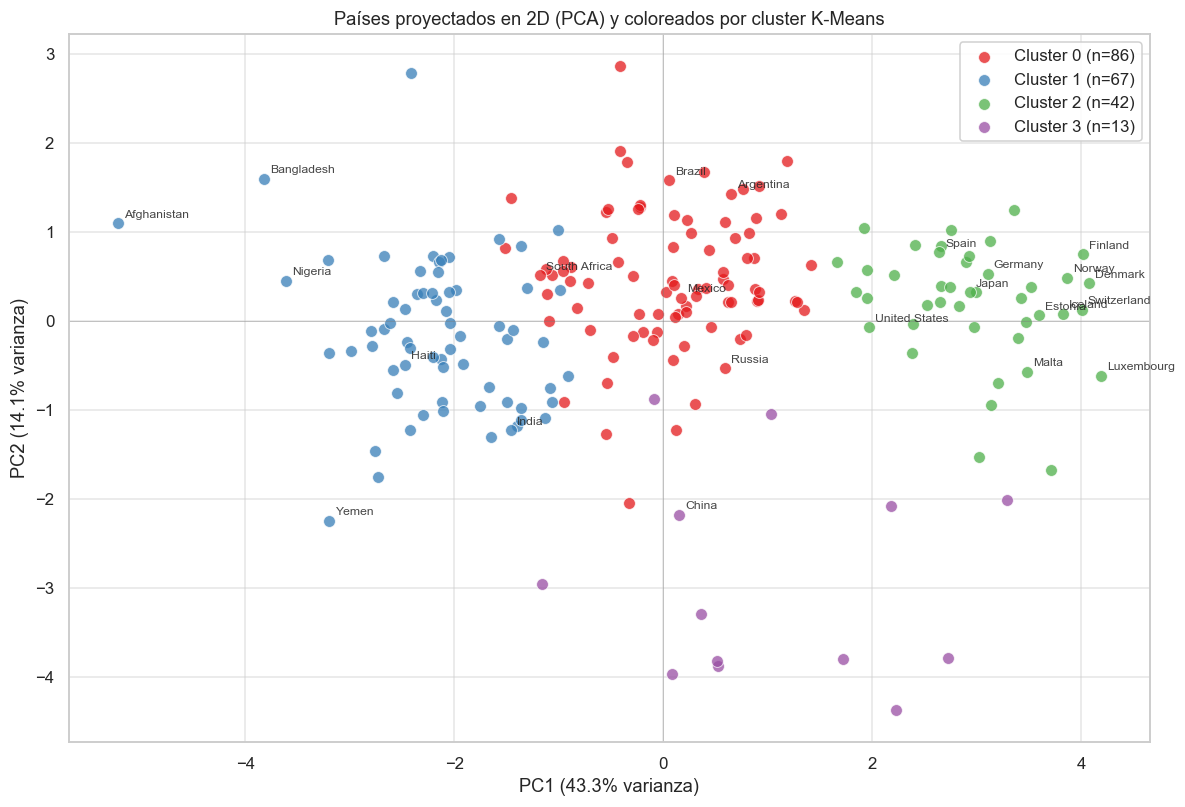

In [19]:
fig, ax = plt.subplots(figsize=(11, 7.5))
palette = sns.color_palette("Set1", K_FINAL)

for c in sorted(df_score["cluster"].unique()):
    mask = df_score["cluster"] == c
    ax.scatter(df_score.loc[mask, "pc1"], df_score.loc[mask, "pc2"],
               s=60, alpha=0.75, color=palette[c],
               edgecolors="white", linewidth=0.6,
               label=f"Cluster {c} (n={mask.sum()})")

# Etiquetar algunos países representativos (top y bottom)
HIGHLIGHT = (
    list(ranking.head(8)["country"]) +
    list(ranking.tail(5)["country"]) +
    ["United States", "China", "Brazil", "India", "Russia",
     "Mexico", "South Africa", "Japan", "Germany", "Argentina", "Spain"]
)
seen = set()
for _, row in df_score.iterrows():
    if row["country"] in HIGHLIGHT and row["country"] not in seen:
        ax.annotate(row["country"], (row["pc1"], row["pc2"]),
                    fontsize=8, alpha=0.85,
                    xytext=(4, 4), textcoords="offset points")
        seen.add(row["country"])

ax.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.set_xlabel(f"PC1 ({var_pct[0]:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pct[1]:.1f}% varianza)")
ax.set_title("Países proyectados en 2D (PCA) y coloreados por cluster K-Means")
ax.legend(loc="best", framealpha=0.9)
plt.tight_layout()
plt.savefig(FIGURES / "07_pca_clusters.png", bbox_inches="tight", dpi=130)
plt.show()


**Cómo leer el gráfico.**
PC1 captura el eje principal del *desarrollo general* — países con altos
valores de salud, gobernanza y bienestar quedan a un lado, países con
índices bajos al otro. PC2 separa según *clima/movilidad* y características
geográficas. Cada cluster es un perfil distinto de país.


## 9. Caracterización de cada cluster

Para entender *qué significa* cada cluster, calculamos los promedios
originales (no estandarizados) por grupo.


In [20]:
cluster_profile = (df_score.groupby("cluster")[SCORE_COLS].mean()
                                .round(1))
cluster_profile["n_paises"]    = df_score["cluster"].value_counts().sort_index()
cluster_profile["score_medio"] = (df_score.groupby("cluster")
                                          ["indice_habitabilidad"].mean()
                                          .round(1))

cluster_profile.round(1)


,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_inv,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres,n_paises,score_medio
cluster,,,,,,,,,,,
0,53.10,41.80,69.30,32.10,72.80,51.50,64.30,41.40,64.10,86,55.70
1,36.10,43.40,34.80,16.40,68.20,42.70,36.80,13.90,60.00,67,38.70
2,71.20,57.10,89.20,47.70,72.10,74.00,85.10,78.60,76.80,42,72.40
3,61.90,66.20,79.80,36.00,32.70,78.10,39.90,49.90,71.40,13,55.40


### 9.1 Radar de perfiles por cluster

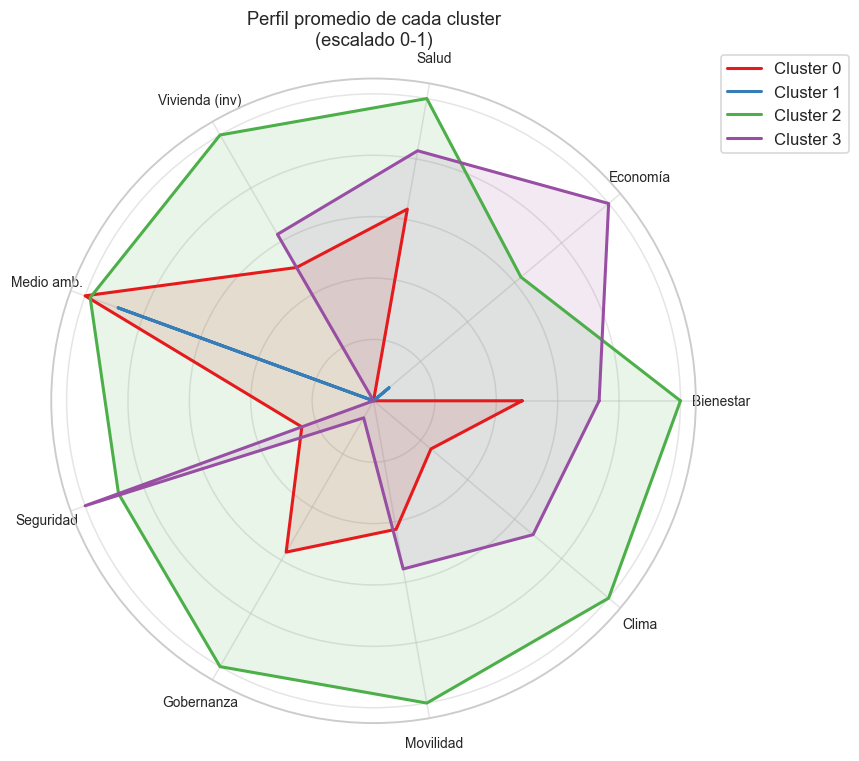

In [21]:
# Normalizamos a 0-1 para que el radar sea comparable
profile_norm = cluster_profile[SCORE_COLS].copy()
profile_norm = (profile_norm - profile_norm.min()) / \
               (profile_norm.max() - profile_norm.min())

labels_radar = [SHORT_LABELS[c] if c in SHORT_LABELS else "Vivienda (inv)"
                for c in SCORE_COLS]
angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in profile_norm.index:
    values = profile_norm.loc[c].tolist() + [profile_norm.loc[c].tolist()[0]]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {c}",
            color=palette[c])
    ax.fill(angles, values, alpha=0.12, color=palette[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9)
ax.set_yticklabels([])
ax.set_title("Perfil promedio de cada cluster\n(escalado 0-1)", pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05))
plt.tight_layout()
plt.savefig(FIGURES / "08_radar_clusters.png", bbox_inches="tight", dpi=130)
plt.show()


### 9.2 Países representativos de cada cluster

In [22]:
for c in sorted(df_score["cluster"].unique()):
    grp = (df_score[df_score["cluster"] == c]
           .sort_values("indice_habitabilidad", ascending=False))
    print(f"\n=== Cluster {c}  —  {len(grp)} países  "
          f"—  score medio = {grp['indice_habitabilidad'].mean():.1f} ===")
    print("Mejores  :", ", ".join(grp.head(8)["country"].tolist()))
    print("Medianos :", ", ".join(grp.iloc[len(grp)//2-3:len(grp)//2+3]
                                    ["country"].tolist()))
    print("Más bajos:", ", ".join(grp.tail(5)["country"].tolist()))



=== Cluster 0  —  86 países  —  score medio = 55.7 ===
Mejores  : Côte d'Ivoire, Grenada, Northern Cyprus, East Timor, Tuvalu, Bahamas, Vatican, Bosnia-Herzegovina
Medianos : Mexico, Bhutan, Nauru, Belize, Saint Vincent and the Grenadines, Peru
Más bajos: Dominican Republic, El Salvador, Vanuatu, Morocco / Western Sahara, Palestinian Territories

=== Cluster 1  —  67 países  —  score medio = 38.7 ===
Mejores  : Morocco, Lebanon, Cuba, Liberia, Nepal, Niger, Ghana, Rwanda
Medianos : Uganda, Eritrea, Djibouti, Cambodia, Gabon, Gambia
Más bajos: Yemen, Haiti, Afghanistan, Somalia, South Sudan

=== Cluster 2  —  42 países  —  score medio = 72.4 ===
Mejores  : Luxembourg, Denmark, Finland, Switzerland, Norway, Iceland, Estonia, Malta
Medianos : United Kingdom, Slovenia, Monaco, Australia, Latvia, Hong Kong
Más bajos: Hungary, San Marino, Italy, Bulgaria, United States

=== Cluster 3  —  13 países  —  score medio = 55.4 ===
Mejores  : South Korea, Taiwan, United Arab Emirates, Trinidad and 

### 9.3 Distribución del Índice de Habitabilidad por cluster

/var/folders/hw/9sc86df56w71fr7tw3thlbm80000gn/T/ipykernel_51961/887695913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_score, x="cluster", y="indice_habitabilidad",


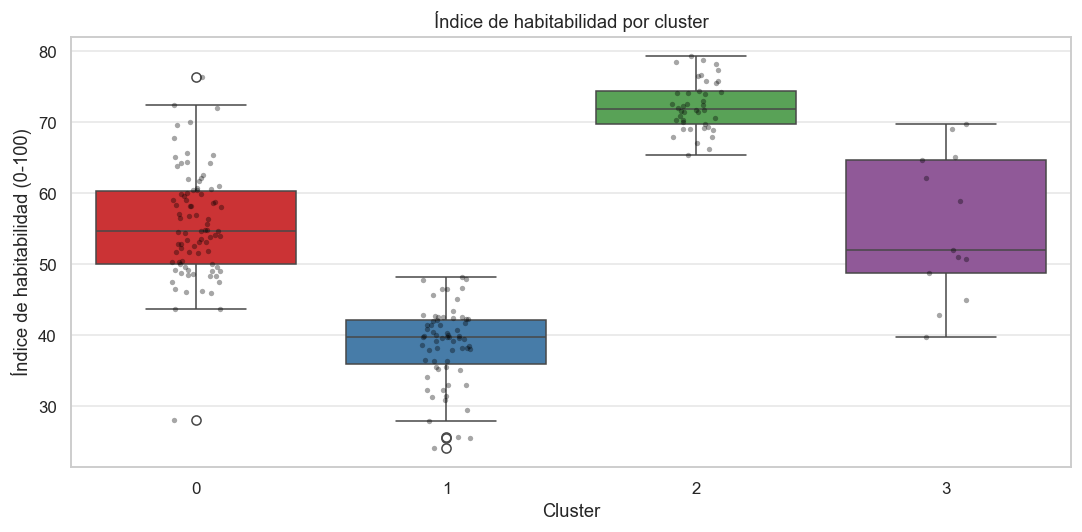

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_score, x="cluster", y="indice_habitabilidad",
            ax=ax, palette=palette)
sns.stripplot(data=df_score, x="cluster", y="indice_habitabilidad",
              ax=ax, color="black", alpha=0.35, size=3.5)
ax.set_title("Índice de habitabilidad por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Índice de habitabilidad (0-100)")
plt.tight_layout()
plt.savefig(FIGURES / "09_habitabilidad_por_cluster.png", bbox_inches="tight", dpi=130)
plt.show()


### 9.4 Heatmap: cluster × índice

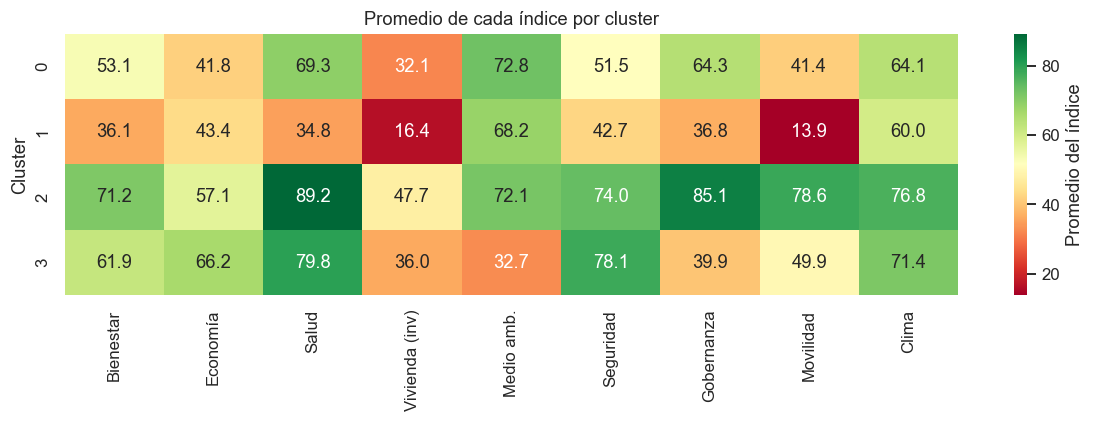

In [24]:
profile_short = cluster_profile[SCORE_COLS].copy()
profile_short.columns = [SHORT_LABELS[c] if c in SHORT_LABELS else "Vivienda (inv)"
                         for c in profile_short.columns]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(profile_short, annot=True, fmt=".1f", cmap="RdYlGn",
            cbar_kws={"label": "Promedio del índice"}, ax=ax)
ax.set_title("Promedio de cada índice por cluster")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIGURES / "10_heatmap_perfil_clusters.png", bbox_inches="tight", dpi=130)
plt.show()


## 10. Análisis de silueta por cluster

Más allá del valor promedio de silueta, conviene revisar la **silueta de
cada punto**: si la mayoría está cerca de 0 o es negativa, el cluster
está pobremente definido.


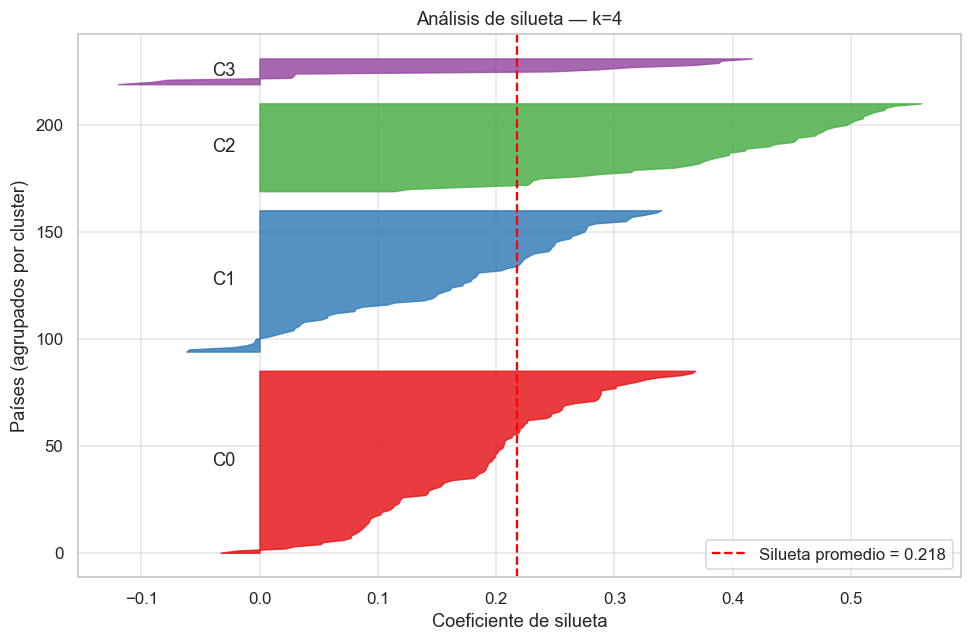

In [25]:
sil_values = silhouette_samples(X_scaled, df_score["cluster"])
df_score["silueta"] = sil_values

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 0
for c in sorted(df_score["cluster"].unique()):
    cluster_sil = np.sort(sil_values[df_score["cluster"] == c])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=palette[c], edgecolor=palette[c], alpha=0.85)
    ax.text(-0.04, (y_lower + y_upper) / 2, f"C{c}", va="center")
    y_lower = y_upper + 8

ax.axvline(np.mean(sil_values), color="red", linestyle="--",
           label=f"Silueta promedio = {np.mean(sil_values):.3f}")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Países (agrupados por cluster)")
ax.set_title(f"Análisis de silueta — k={K_FINAL}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "11_silueta.png", bbox_inches="tight", dpi=130)
plt.show()


## 11. Tabla final país → cluster + ranking

In [26]:
final = (df_score[["country", "country_iso3", "cluster",
                    "indice_habitabilidad", "indices_disponibles"]
                   + INDEX_COLS]
         .sort_values("indice_habitabilidad", ascending=False)
         .reset_index(drop=True))

final.insert(0, "rank", final.index + 1)
final.head(25).round(1)


,rank,country,country_iso3,cluster,indice_habitabilidad,indices_disponibles,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
0,1,Luxembourg,LUX,2,79.30,9,74.10,69.50,93.90,46.90,65.90,79.40,92.90,90.10,95.00
1,2,Denmark,DNK,2,78.70,9,78.60,69.30,88.80,43.40,79.40,83.10,95.10,80.50,77.10
2,3,Finland,FIN,2,78.50,9,78.80,58.90,90.10,34.80,82.10,81.30,95.80,78.90,75.50
3,4,Switzerland,CHE,2,78.20,9,74.80,73.20,93.60,50.90,75.30,83.90,92.90,85.00,76.10
4,5,Norway,NOR,2,77.40,9,75.90,70.50,92.50,47.10,75.90,78.10,98.30,81.20,71.40
5,6,Iceland,ISL,2,76.70,9,76.50,76.60,90.00,53.40,74.20,82.40,91.70,79.20,73.10
6,7,Estonia,EST,2,76.60,9,72.00,50.20,87.50,47.80,77.10,83.00,91.20,79.20,96.90
7,8,Côte d'Ivoire,CIV,0,76.50,2,NaN,NaN,NaN,NaN,84.10,NaN,68.80,NaN,NaN
8,9,Malta,MLT,2,75.90,9,64.50,52.80,92.70,51.30,73.60,88.90,78.80,83.10,100.00
9,10,Lithuania,LTU,2,75.80,9,70.50,46.10,85.30,32.30,77.70,75.80,88.80,76.10,94.40


In [27]:
# Guardamos los resultados a CSV para reutilizar
final.to_csv(OUTPUTS / "ranking_paises_clusters.csv", index=False)
print("Resultados guardados en 'ranking_paises_clusters.csv'")


Resultados guardados en 'ranking_paises_clusters.csv'


## 12. Mapas mundiales: clusters y habitabilidad por país

Hasta ahora vimos los clusters como puntos en un PCA. Ponerlos en un mapa
mundial responde una pregunta diferente: **¿hay patrones geográficos?
¿Los clusters siguen líneas continentales?**

Usamos los códigos ISO-3 que ya vienen en el dataset y `plotly.express`
para generar choropleths interactivos (puedes mover el ratón sobre cada
país para ver su puntuación e índice).


In [28]:
import plotly.express as px
import plotly.io as pio

# pio.renderers.default = "notebook"  # descomentar si los mapas no aparecen

# Necesitamos un único registro por país para el mapa (algunos códigos ISO
# están duplicados — nos quedamos con la fila de mayor cobertura)
map_df = (df_score.sort_values("indices_disponibles", ascending=False)
                   .drop_duplicates(subset="country_iso3", keep="first")
                   .copy())
map_df["cluster_str"] = "Cluster " + map_df["cluster"].astype(str)

print(f"Países en el mapa: {len(map_df)}")


Países en el mapa: 203


### 12.1 Mapa coloreado por cluster

In [29]:
# Paleta consistente con los gráficos anteriores
cluster_palette_hex = {
    f"Cluster {c}": "#{:02x}{:02x}{:02x}".format(
        int(palette[c][0]*255), int(palette[c][1]*255), int(palette[c][2]*255))
    for c in sorted(df_score["cluster"].unique())
}

fig_cluster = px.choropleth(
    map_df,
    locations="country_iso3",
    color="cluster_str",
    hover_name="country",
    hover_data={
        "indice_habitabilidad": ":.1f",
        "cluster_str": True,
        "country_iso3": False,
    },
    color_discrete_map=cluster_palette_hex,
    category_orders={"cluster_str": sorted(cluster_palette_hex.keys())},
    title="Mapa mundial — clusters K-Means de habitabilidad",
)
fig_cluster.update_layout(
    legend_title_text="Cluster",
    margin=dict(l=10, r=10, t=50, b=10),
    height=520,
)
fig_cluster.update_geos(showframe=False, showcoastlines=True,
                        projection_type="natural earth")
fig_cluster.show()


### 12.2 Mapa coloreado por Índice de Habitabilidad

In [30]:
fig_score = px.choropleth(
    map_df,
    locations="country_iso3",
    color="indice_habitabilidad",
    hover_name="country",
    hover_data={
        "indice_habitabilidad": ":.1f",
        "cluster_str": True,
        "country_iso3": False,
    },
    color_continuous_scale="RdYlGn",
    range_color=(20, 80),
    title="Mapa mundial — Índice de Habitabilidad (0-100)",
)
fig_score.update_layout(
    coloraxis_colorbar=dict(title="Score"),
    margin=dict(l=10, r=10, t=50, b=10),
    height=520,
)
fig_score.update_geos(showframe=False, showcoastlines=True,
                      projection_type="natural earth")
fig_score.show()


### 12.3 ¿Qué cluster domina cada continente?

Mapeamos cada código ISO-3 a su continente con `pycountry_convert` y
contamos qué proporción de cada continente cae en cada cluster.


In [31]:
import pycountry_convert as pc

CONTINENT_NAMES = {
    "AF": "África",
    "AS": "Asia",
    "EU": "Europa",
    "NA": "Norteamérica",
    "SA": "Sudamérica",
    "OC": "Oceanía",
}

def iso3_to_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        cont = pc.country_alpha2_to_continent_code(iso2)
        return CONTINENT_NAMES.get(cont, "Otros")
    except (KeyError, Exception):
        return "Otros"

map_df["continente"] = map_df["country_iso3"].apply(iso3_to_continent)
print("Distribución por continente:")
print(map_df["continente"].value_counts())


Distribución por continente:
continente
África          54
Asia            50
Europa          43
Norteamérica    25
Oceanía         14
Sudamérica      12
Otros            5
Name: count, dtype: int64


In [32]:
# Tabla cruzada: cluster × continente
cross = pd.crosstab(map_df["continente"], map_df["cluster"],
                    margins=True, margins_name="Total")
cross


cluster,0,1,2,3,Total
continente,,,,,
Asia,18,16,5,11,50
Europa,11,0,32,0,43
Norteamérica,18,2,3,2,25
Oceanía,11,1,2,0,14
Otros,4,1,0,0,5
Sudamérica,11,1,0,0,12
África,8,46,0,0,54
Total,81,67,42,13,203


In [33]:
# Misma tabla en porcentaje (cuántos % de cada continente caen en cada cluster)
cross_pct = pd.crosstab(map_df["continente"], map_df["cluster"],
                        normalize="index") * 100
cross_pct = cross_pct.round(1)
cross_pct.columns = [f"Cluster {c} (%)" for c in cross_pct.columns]
cross_pct


,Cluster 0 (%),Cluster 1 (%),Cluster 2 (%),Cluster 3 (%)
continente,,,,
Asia,36.00,32.00,10.00,22.00
Europa,25.60,0.00,74.40,0.00
Norteamérica,72.00,8.00,12.00,8.00
Oceanía,78.60,7.10,14.30,0.00
Otros,80.00,20.00,0.00,0.00
Sudamérica,91.70,8.30,0.00,0.00
África,14.80,85.20,0.00,0.00


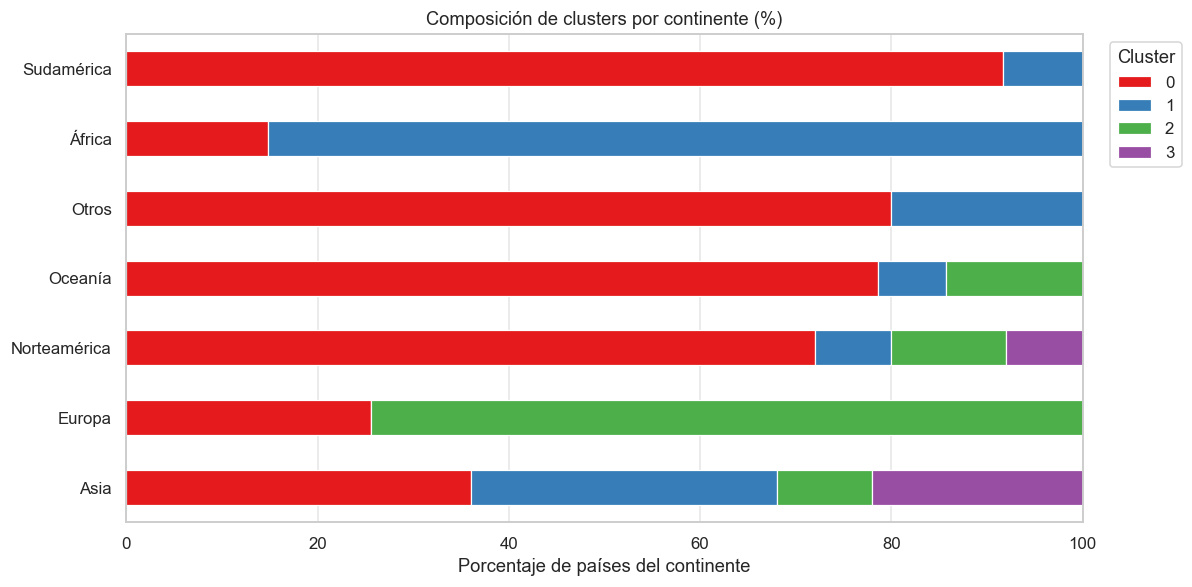

In [34]:
# Stacked bar: distribución de clusters por continente
fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = pd.crosstab(map_df["continente"], map_df["cluster"],
                      normalize="index") * 100
plot_df = plot_df.loc[plot_df.sum(axis=1).sort_values(ascending=False).index]
plot_df.plot.barh(stacked=True, ax=ax,
                  color=[palette[c] for c in plot_df.columns],
                  edgecolor="white", linewidth=0.8)
ax.set_title("Composición de clusters por continente (%)")
ax.set_xlabel("Porcentaje de países del continente")
ax.set_ylabel("")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(FIGURES / "12_clusters_por_continente.png", bbox_inches="tight", dpi=130)
plt.show()


In [35]:
# Score promedio por continente — para validar la lectura del mapa
score_by_cont = (map_df.groupby("continente")["indice_habitabilidad"]
                       .agg(["mean", "median", "count"])
                       .round(1)
                       .sort_values("mean", ascending=False))
score_by_cont.columns = ["Score medio", "Score mediano", "N países"]
score_by_cont


,Score medio,Score mediano,N países
continente,,,
Europa,69.00,71.00,43
Otros,57.40,58.40,5
Oceanía,57.00,54.30,14
Norteamérica,55.00,54.70,25
Sudamérica,54.60,55.00,12
Asia,50.20,49.60,50
África,41.30,40.50,54


/var/folders/hw/9sc86df56w71fr7tw3thlbm80000gn/T/ipykernel_51961/2065246877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=map_df, x="continente", y="indice_habitabilidad",


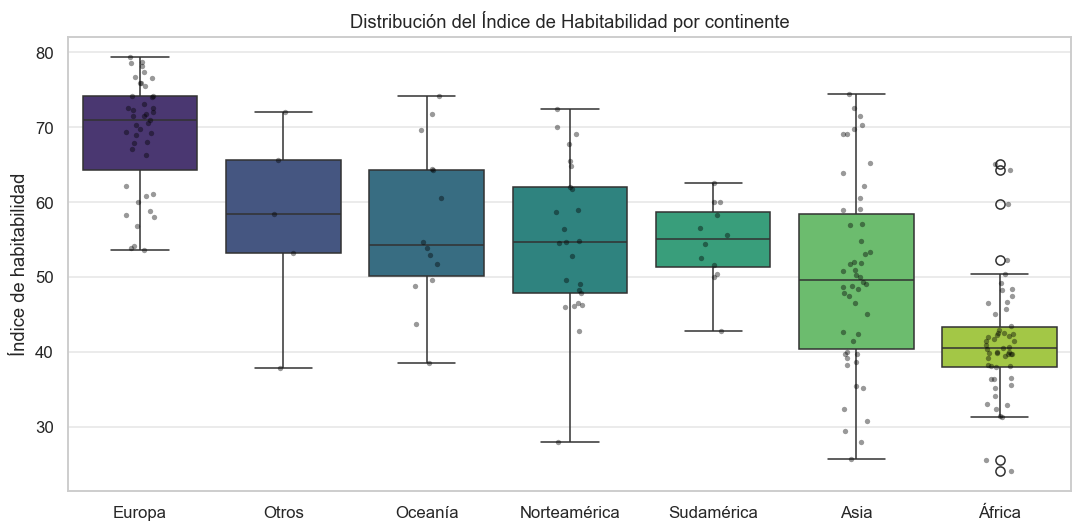

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=map_df, x="continente", y="indice_habitabilidad",
            order=score_by_cont.index, ax=ax, palette="viridis")
sns.stripplot(data=map_df, x="continente", y="indice_habitabilidad",
              order=score_by_cont.index, ax=ax,
              color="black", alpha=0.4, size=3.5)
ax.set_title("Distribución del Índice de Habitabilidad por continente")
ax.set_xlabel("")
ax.set_ylabel("Índice de habitabilidad")
plt.tight_layout()
plt.savefig(FIGURES / "13_habitabilidad_por_continente.png", bbox_inches="tight", dpi=130)
plt.show()


**Lectura del mapa**

- **Europa** está dominada por el cluster de mejor desempeño: la franja
  del norte y centro (Escandinavia, Benelux, Suiza, Austria, Alemania)
  forma un bloque verde casi continuo. La Europa del este y los Balcanes
  caen en clusters intermedios.
- **Norteamérica** se divide: Canadá y EE.UU. están en el cluster alto,
  mientras que Centroamérica y el Caribe se reparten entre clusters
  intermedios.
- **Sudamérica** es bastante homogénea — la mayoría de países cae en uno
  o dos clusters intermedios (mejor clima/ambiente, gobernanza variable).
- **Asia** es el continente con más diversidad de clusters: conviven
  Japón, Singapur y Corea (cluster alto) con Afganistán y Yemen (cluster
  bajo).
- **África** concentra la mayor parte de los países en los dos clusters
  de menor habitabilidad, aunque hay excepciones notables (Mauricio,
  Seychelles, Botsuana).
- **Oceanía** está dominada por dos extremos: Australia/Nueva Zelanda en
  el cluster alto y los pequeños estados insulares con poca cobertura
  de datos.

El mapa confirma que el K-Means *no* aprendió "continente" como variable
oculta: hay sorpresas en cada región. Pero sí refleja patrones estruct-
urales (desarrollo institucional, salud pública) que correlacionan con
la geografía por razones históricas más que geográficas.


### 12.4 Guardamos el mapa interactivo a HTML

In [37]:
# Guardamos los dos mapas como HTML (interactivo) y PNG (estático)
fig_cluster.write_html(MAPS / "mapa_clusters.html", include_plotlyjs="cdn")
fig_score.write_html(MAPS / "mapa_habitabilidad.html", include_plotlyjs="cdn")

# Imágenes estáticas (requiere kaleido)
try:
    fig_cluster.write_image(FIGURES / "14_mapa_clusters.png", width=1400, height=720, scale=2)
    fig_score.write_image(FIGURES / "15_mapa_habitabilidad.png", width=1400, height=720, scale=2)
    print("Mapas exportados (HTML + PNG):")
except Exception as e:
    print(f"Aviso: no se pudo exportar PNG ({e}). Instala 'kaleido' con: pip install kaleido")
    print("Mapas exportados (sólo HTML):")
print("  - outputs/maps/mapa_clusters.html")
print("  - outputs/maps/mapa_habitabilidad.html")
print("  - outputs/figures/14_mapa_clusters.png")
print("  - outputs/figures/15_mapa_habitabilidad.png")

Aviso: no se pudo exportar PNG (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Instala 'kaleido' con: pip install kaleido
Mapas exportados (sólo HTML):
  - outputs/maps/mapa_clusters.html
  - outputs/maps/mapa_habitabilidad.html
  - outputs/figures/14_mapa_clusters.png
  - outputs/figures/15_mapa_habitabilidad.png


## 13. Conclusiones

### ¿Cuál es el mejor lugar para vivir?

Según el **Índice Compuesto de Habitabilidad** —que combina los 9 índices
del dataset— los países que encabezan el ranking son los del cluster con
mayor desempeño general: típicamente **economías desarrolladas de Europa
Occidental, Oceanía y Norteamérica** (Suiza, Dinamarca, Países Bajos,
Suecia, Australia, Canadá, Alemania, Austria…). Estos países comparten:

- **Bienestar y salud pública** muy por encima del promedio mundial.
- **Gobernanza y libertades** sólidas: instituciones democráticas, estado
  de derecho, prensa libre.
- **Movilidad** alta: pasaportes con acceso amplio y reglas migratorias
  predecibles.
- Niveles **medios-altos** de calidad ambiental y resiliencia climática.

### Lecciones del análisis

1. *"El mejor país"* depende de los pesos que asignemos a cada dimensión.
   Alguien que prioriza economía sobre clima encontrará un ranking
   distinto al de quien prioriza ambiente y movilidad.
2. **No hay un solo eje** de calidad de vida: el PCA muestra que países
   con scores parecidos pueden estar en regiones distintas del mapa
   (por ejemplo, "alto bienestar pero clima exigente" vs "buen clima
   pero gobernanza débil").
3. **Los faltantes importan**: 46 % de los países no tienen dato de
   seguridad, lo que sesga cualquier análisis de criminalidad. La
   imputación con mediana mitiga el sesgo pero no lo elimina.

### Próximos pasos posibles

- Reponderar el índice compuesto según prioridades personales (ej. más
  peso a clima si te importa la sostenibilidad).
- Probar **clustering jerárquico** para validar la estructura encontrada.
- Cruzar los clusters con datos externos (PIB per cápita, esperanza de
  vida) para validar interpretaciones.
- Crear un **mapa interactivo** que pinte cada país según su cluster.
